Demo version of Smart Investor App
** Features **
- Google Market Historical Stock 
- Deep Q-Network Algorithm for Reinforcement Learning 
- Agent that predicting Google Stock Prices using past market values 
- Algorithm configuration parameters
- Charts with testing summary

In [1]:
import yfinance as yf
import pandas as pd
from Utils import print_plot, sma

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mzwie\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mzwie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
data = yf.download("GOOGL", start="2010-01-01", end="2024-06-01")

[*********************100%%**********************]  1 of 1 completed


In [3]:
data_length = len(data)

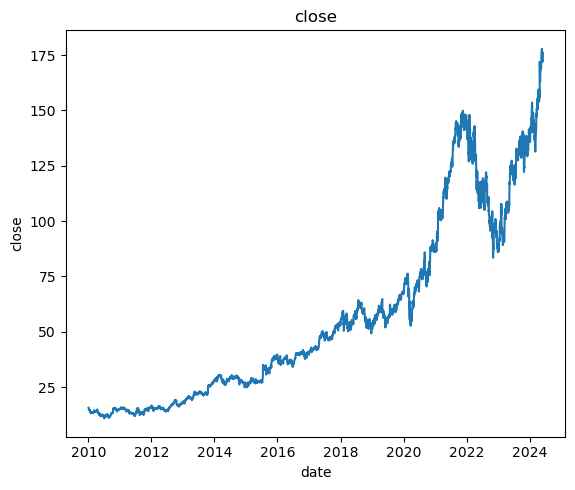

In [4]:
print_plot(data.reset_index().rename(columns={"Date": "date", "Close": "close"}), 'close')

RL Settings
- States: MONEY, NEW PRICE, NUM ACTIONS, TOTAL ASSETS VALUE
- Actions: BUY 1, SELL 1, HOLD
- Score: ALL ASSETS CURR > ALL ASSETS PREV ? 10 : -10

In [5]:
import random
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf

In [6]:
STATE_SIZE = 4
ACTION_SIZE = 3
STARTING_MONEY = 1000
EPISODES = 10
MEMORY_LENGTH = 5000
BATCH_SIZE = 64
STEPS = data_length - 1
GAMMA = .95
EPSILON_DECAY = .995
EPSILON_MIN = .01
EPSILON = 1

In [7]:
class Env():
    def __init__(self, starting_money, data):
        self.state = 0
        self.starting_money = starting_money
        self.money = starting_money
        self.data = data
        self.stock_actions = 0
        print("Env created")
    def reset(self):
        self.state = 0
        self.stock_actions = 0
        self.money = self.starting_money
        assets_value = self.money + self.stock_actions * 0
        return [self.money, 0, 0, assets_value]
    def step(self, action):
        prev_price = data["Close"][self.state]
        prev_assets_value = self.money + self.stock_actions * prev_price
        self.state += 1
        new_price = data["Close"][self.state]
        if action == 0 and self.money >= new_price: #BUY
            self.stock_actions += 1
            self.money = self.money - new_price
        elif action == 1 and self.stock_actions > 0: #SELL
            self.stock_actions -= 1
            self.money = self.money + new_price
        new_assets_value = self.money + self.stock_actions * new_price
        if self.state <= len(data):
            done = False
        else:
            done = True
        if new_assets_value > prev_assets_value:
            reward = 10
        elif new_assets_value == prev_assets_value:
            reward = 0
        else:
            reward = -10
        new_state = [self.money, new_price, self.stock_actions, new_assets_value]
        return new_state, reward, done

In [8]:
class DQNAgent():
    def __init__(self, epsilon, epsilon_min, epsilon_decay, gamma, batch_size):
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.gamma = gamma
        self.batch_size = batch_size
        self.create_model()
        self.memory = deque(maxlen=MEMORY_LENGTH)
    
    def create_model(self):
        self.model = Sequential()
        self.model.add(Input(shape=(STATE_SIZE,)))
        self.model.add(Dense(32, activation='relu'))
        self.model.add(Dense(32, activation='relu'))
        self.model.add(Dense(ACTION_SIZE, activation='linear'))
        self.model.compile(loss='mse', optimizer='adam')
        
    def act(self, state):
        if random.uniform(0,1) < self.epsilon:
            return random.randrange(ACTION_SIZE)
        else:
            q_values = self.model.predict(state, verbose=0)
            return np.argmax(q_values[0])
    
    def remember(self, state, action, reward, new_state, done):
        self.memory.append((state, action, reward, new_state, done))
        
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([sample[0] for sample in minibatch]).reshape(self.batch_size, STATE_SIZE)
        actions = np.array([sample[1] for sample in minibatch])
        rewards = np.array([sample[2] for sample in minibatch])
        new_states = np.array([sample[3] for sample in minibatch]).reshape(self.batch_size, STATE_SIZE)
        done = np.array([sample[4] for sample in minibatch])
        target = rewards + (1 - done) * self.gamma * np.amax(self.model.predict(new_states, verbose=0), axis=1)
        target_full = self.model.predict(states, verbose=0)
        for i, action in enumerate(actions):
            target_full[i, action] = target[i]
        self.model.fit(states, target_full, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [9]:
from sklearn.preprocessing import StandardScaler

def get_scaler(env):
    states = []
    env.reset()
    for _ in range(STEPS):
        action = random.randrange(ACTION_SIZE)
        new_state, reward, done = env.step(action)
        states.append(new_state)
        if done:
            break
    scaler = StandardScaler()
    scaler.fit(states)
    return scaler

In [ ]:
import warnings
import time

warnings.filterwarnings('ignore')
agent = DQNAgent(epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY, gamma=GAMMA, batch_size=BATCH_SIZE)
env = Env(STARTING_MONEY, data)
scaler = get_scaler(env)
for episode in range(EPISODES):
    print(f"Episode {episode}")
    start = time.time()
    state = [env.reset()]
    total_reward = 0
    for step in range(STEPS):
        print(f"Step {step}")
        state = scaler.transform(state)
        action = agent.act(state)
        new_state, reward, done = env.step(action)
        new_state = scaler.transform([new_state])
        agent.remember(state, action, reward, new_state, done)
        state = new_state
        total_reward += reward
        if done:
            print(f"Episode {episode+1}/{EPISODES}, Reward: {total_reward}, Epsilon: {agent.epsilon}")
            break
        agent.replay()
    end = time.time()
    print(f"Time elapsed: {end - start}")



Env created
Episode 0
Step 0
Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45
Step 46
Step 47
Step 48
Step 49
Step 50
Step 51
Step 52
Step 53
Step 54
Step 55
Step 56
Step 57
Step 58
Step 59
Step 60
Step 61
Step 62
Step 63

Step 64
Step 65
Step 66
Step 67
Step 68
Step 69
Step 70
Step 71
Step 72
Step 73
Step 74
Step 75
Step 76
Step 77
Step 78
Step 79
Step 80
Step 81
Step 82
Step 83
Step 84
Step 85
Step 86
Step 87
Step 88
Step 89
Step 90
Step 91
Step 92
Step 93
Step 94
Step 95
Step 96
Step 97
Step 98
Step 99
Step 100
Step 101
Step 102
Step 103
Step 104
Step 105
Step 106
Step 107
Step 108
Step 109
Step 110
Step 111
Step 112
Step 113
Step 114
Step 115
Step 116
Step 117
Step 118
Step 119
Step 

In [ ]:
# state = env.reset()[0]
# state = preprocess_state(state)
# i = 0
# while True:
#     q_values = agent.model.predict(state, verbose=0)
#     action = np.argmax(q_values[0])
#     new_state, reward, done, _, _ = env.step(action)
#     env.render()
#     i+=1
#     if done or i >=100:
#         print("Done!")
#         break
#     state = preprocess_state(new_state)